In [4]:
import pandas as pd

df = pd.read_csv("ai4i2020.csv")

print(df.shape)
print(df.columns)

(10000, 14)
Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')


In [5]:
# Remove unnecessary columns

df = df.drop(['UDI', 'Product ID'], axis=1)

print(df.head())
print(df.shape)

  Type  Air temperature [K]  Process temperature [K]  Rotational speed [rpm]  \
0    M                298.1                    308.6                    1551   
1    L                298.2                    308.7                    1408   
2    L                298.1                    308.5                    1498   
3    L                298.2                    308.6                    1433   
4    L                298.2                    308.7                    1408   

   Torque [Nm]  Tool wear [min]  Machine failure  TWF  HDF  PWF  OSF  RNF  
0         42.8                0                0    0    0    0    0    0  
1         46.3                3                0    0    0    0    0    0  
2         49.4                5                0    0    0    0    0    0  
3         39.5                7                0    0    0    0    0    0  
4         40.0                9                0    0    0    0    0    0  
(10000, 12)


In [6]:
# Check target variable

print(df['Machine failure'].value_counts())

Machine failure
0    9661
1     339
Name: count, dtype: int64


In [7]:
# Check data types

print(df.dtypes)

Type                        object
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object


In [8]:
# Convert Type column to numeric values

df['Type'] = df['Type'].map({
    'L': 0,
    'M': 1,
    'H': 2
})

print(df.head())

   Type  Air temperature [K]  Process temperature [K]  Rotational speed [rpm]  \
0     1                298.1                    308.6                    1551   
1     0                298.2                    308.7                    1408   
2     0                298.1                    308.5                    1498   
3     0                298.2                    308.6                    1433   
4     0                298.2                    308.7                    1408   

   Torque [Nm]  Tool wear [min]  Machine failure  TWF  HDF  PWF  OSF  RNF  
0         42.8                0                0    0    0    0    0    0  
1         46.3                3                0    0    0    0    0    0  
2         49.4                5                0    0    0    0    0    0  
3         39.5                7                0    0    0    0    0    0  
4         40.0                9                0    0    0    0    0    0  


In [9]:

print(df['Type'].value_counts())

Type
0    6000
1    2997
2    1003
Name: count, dtype: int64


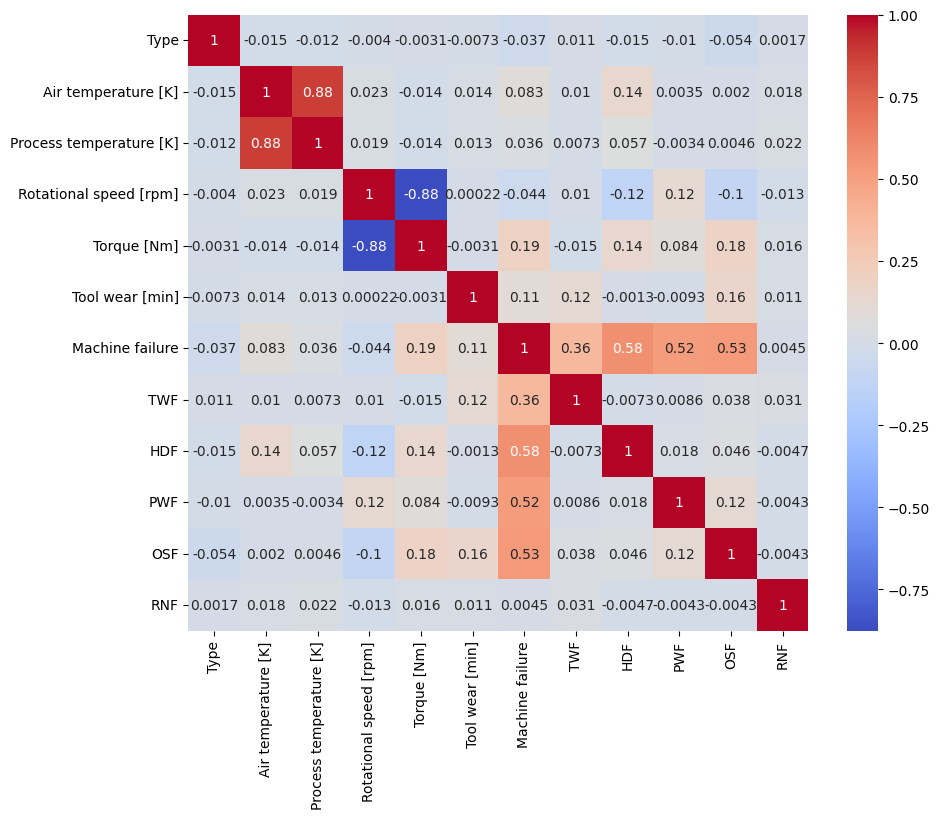

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [11]:
from sklearn.model_selection import train_test_split

X = df.drop('Machine failure', axis=1)
y = df['Machine failure']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(8000, 11)
(2000, 11)


In [12]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [13]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.999


In [14]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1939
           1       1.00      0.97      0.98        61

    accuracy                           1.00      2000
   macro avg       1.00      0.98      0.99      2000
weighted avg       1.00      1.00      1.00      2000



                    Feature  Importance
7                       HDF    0.305343
9                       OSF    0.213352
8                       PWF    0.176225
6                       TWF    0.109435
4               Torque [Nm]    0.076182
3    Rotational speed [rpm]    0.050486
5           Tool wear [min]    0.035356
1       Air temperature [K]    0.017053
2   Process temperature [K]    0.012277
0                      Type    0.003586
10                      RNF    0.000705


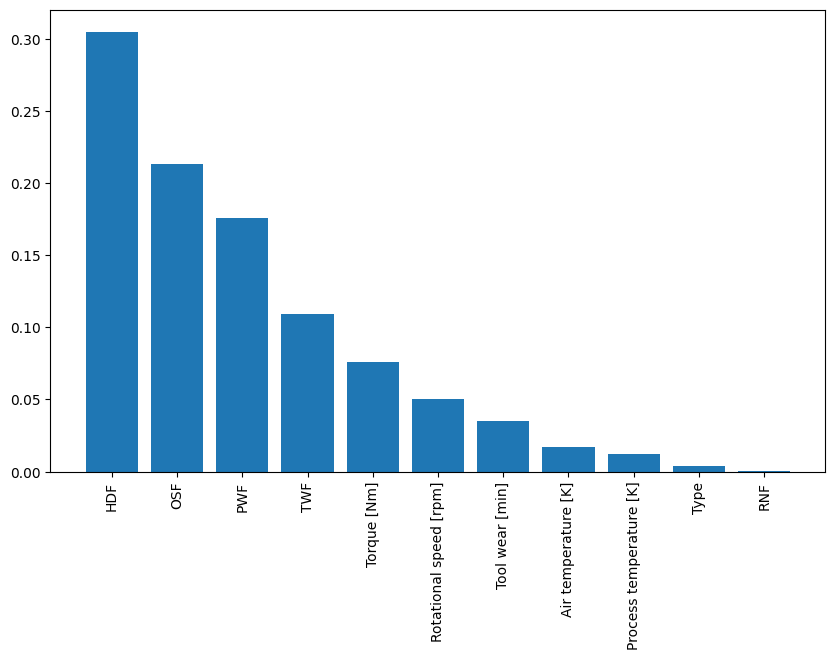

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

importance = model.feature_importances_

features = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

features = features.sort_values(
    by='Importance',
    ascending=False
)

print(features)

plt.figure(figsize=(10,6))
plt.bar(features['Feature'], features['Importance'])
plt.xticks(rotation=90)
plt.show()

In [16]:
X = df.drop("Machine failure", axis=1)
y = df["Machine failure"]

In [17]:
print(df.columns.tolist())


['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']


In [18]:
print(X.columns.tolist())

['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']


In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [20]:
!pip install lightgbm imbalanced-learn

In [21]:
from imblearn.over_sampling import SMOTE
from lightgbm import LGBMClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [22]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Original Training Shape:", X_train.shape)
print("After SMOTE:", X_train_smote.shape)

Original Training Shape: (8000, 11)
After SMOTE: (15458, 11)


In [23]:
from lightgbm import LGBMClassifier
import re

# Function to sanitize column names
def sanitize_col_names(df):
    cols = df.columns
    new_cols = []
    for col in cols:
        # Replace [ and ] with empty string, and spaces with underscores
        new_col = re.sub(r'[\\/\[\]<>]', '', col) # Removed other special chars as well for robust sanitization
        new_col = re.sub(r'\s+', '_', new_col)
        new_cols.append(new_col)
    df.columns = new_cols
    return df

# Sanitize column names in X_train_smote and X_test
X_train_smote = sanitize_col_names(X_train_smote.copy())
X_test = sanitize_col_names(X_test.copy())

model = LGBMClassifier(
    random_state=42,
    n_estimators=100
)

model.fit(X_train_smote, y_train_smote)

[LightGBM] [Info] Number of positive: 7729, number of negative: 7729
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002720 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1280
[LightGBM] [Info] Number of data points in the train set: 15458, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


LGBMClassifier(random_state=42)

In [24]:
y_pred = model.predict(X_test)

In [25]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.989


In [26]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Precision: 0.7674418604651163
Recall: 0.9705882352941176
F1 Score: 0.8571428571428571


In [27]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99      1932
           1       0.77      0.97      0.86        68

    accuracy                           0.99      2000
   macro avg       0.88      0.98      0.93      2000
weighted avg       0.99      0.99      0.99      2000



In [28]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[1912   20]
 [   2   66]]


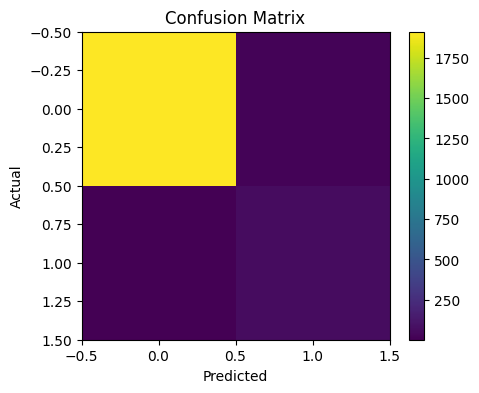

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))
plt.imshow(cm)

plt.title("Confusion Matrix")
plt.colorbar()

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

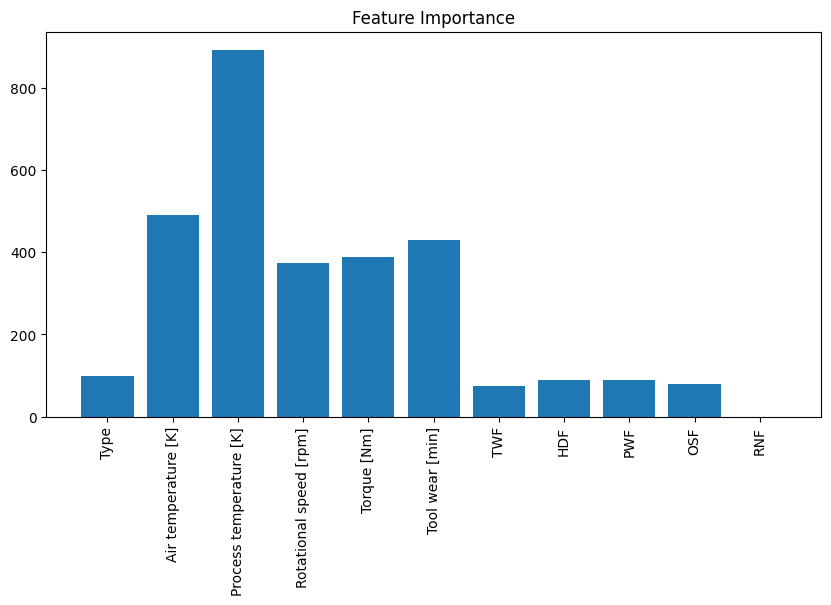

In [30]:
importance = model.feature_importances_

features = X.columns

plt.figure(figsize=(10,5))

plt.bar(features, importance)

plt.xticks(rotation=90)

plt.title("Feature Importance")

plt.show()

In [31]:
print(X_train_smote.shape)
print(y_train_smote.shape)

(15458, 11)
(15458,)


In [32]:
import re

# Create a copy
X_cv = X.copy()

# Clean column names
X_cv.columns = [
    re.sub(r'[^A-Za-z0-9_]', '_', col)
    for col in X_cv.columns
]

print(X_cv.columns)

Index(['Type', 'Air_temperature__K_', 'Process_temperature__K_',
       'Rotational_speed__rpm_', 'Torque__Nm_', 'Tool_wear__min_', 'TWF',
       'HDF', 'PWF', 'OSF', 'RNF'],
      dtype='object')


In [33]:
from sklearn.model_selection import cross_val_score
from lightgbm import LGBMClassifier

model_cv = LGBMClassifier(
    random_state=42,
    n_estimators=100
)

scores = cross_val_score(
    model_cv,
    X_cv,
    y,
    cv=5,
    scoring="accuracy"
)

print("Cross Validation Scores:", scores)
print("Average Accuracy:", scores.mean())

[LightGBM] [Info] Number of positive: 272, number of negative: 7728
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001254 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 905
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.034000 -> initscore=-3.346803
[LightGBM] [Info] Start training from score -3.346803
[LightGBM] [Info] Number of positive: 271, number of negative: 7729
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001428 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 937
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.033875 -> initscore=-3.350616
[LightGBM] [

In [34]:
cv_results = {
    "Cross Validation Scores": scores,
    "Average Accuracy": scores.mean()
}

print(cv_results)

{'Cross Validation Scores': array([0.9995, 0.999 , 0.8905, 0.998 , 0.999 ]), 'Average Accuracy': np.float64(0.9771999999999998)}


In [37]:
""

''

In [38]:
X_test_noisy = X_test.copy()

In [39]:
import numpy as np

In [40]:
noise = np.random.normal(
    0,
    0.1,
    X_test.shape
)

In [41]:
X_test_noisy = X_test + noise

In [42]:
y_pred_noisy = model.predict(X_test_noisy)

In [43]:
from sklearn.metrics import accuracy_score

print("Original Accuracy")

print(accuracy_score(y_test, y_pred))

print("Noisy Accuracy")

print(accuracy_score(y_test, y_pred_noisy))

Original Accuracy
0.989
Noisy Accuracy
0.099


In [44]:
from sklearn.metrics import precision_score

print("Original Precision")

print(precision_score(y_test,y_pred))

print("Noisy Precision")

print(precision_score(y_test,y_pred_noisy))

Original Precision
0.7674418604651163
Noisy Precision
0.03636363636363636


In [45]:
from sklearn.metrics import recall_score

print("Original Recall")

print(recall_score(y_test,y_pred))

print("Noisy Recall")

print(recall_score(y_test,y_pred_noisy))

Original Recall
0.9705882352941176
Noisy Recall
1.0


In [46]:
from sklearn.metrics import f1_score

print("Original F1")

print(f1_score(y_test,y_pred))

print("Noisy F1")

print(f1_score(y_test,y_pred_noisy))


Original F1
0.8571428571428571
Noisy F1
0.07017543859649122


In [47]:
y_prob = model.predict_proba(X_test)[:,1]

In [48]:
threshold = 0.3

y_pred_03 = (y_prob>=threshold).astype(int)

In [49]:
print(classification_report(
    y_test,
    y_pred_03
))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99      1932
           1       0.62      0.97      0.75        68

    accuracy                           0.98      2000
   macro avg       0.81      0.97      0.87      2000
weighted avg       0.99      0.98      0.98      2000



In [50]:
threshold = 0.5

y_pred_05 = (y_prob>=threshold).astype(int)

print(classification_report(
    y_test,
    y_pred_05
))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99      1932
           1       0.77      0.97      0.86        68

    accuracy                           0.99      2000
   macro avg       0.88      0.98      0.93      2000
weighted avg       0.99      0.99      0.99      2000



In [51]:
threshold = 0.7

y_pred_07 = (y_prob>=threshold).astype(int)

print(classification_report(
    y_test,
    y_pred_07
))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00      1932
           1       0.87      0.97      0.92        68

    accuracy                           0.99      2000
   macro avg       0.93      0.98      0.96      2000
weighted avg       0.99      0.99      0.99      2000



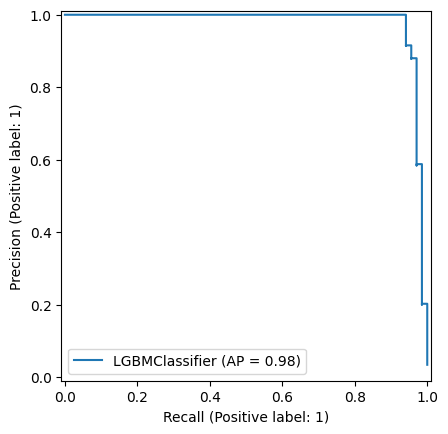

In [52]:
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_estimator(
    model,
    X_test,
    y_test
)

Week 4 Observations

• Noise slightly reduced model performance.
• Precision and Recall changed when threshold changed.
• Lower threshold increased Recall.
• Higher threshold increased Precision.
• The model remained reasonably robust under moderate noise.